In [5]:
import os
import numpy as np

In [6]:
def txt_to_numpy(filename):
    data = []
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.replace(",", ".").split()
            if len(parts) >= 3:
                try:
                    row = [float(parts[0]), float(parts[1]), float(parts[2])]
                    data.append(row)
                except ValueError:
                    pass
    return np.array(data, dtype=float)

In [7]:
def convert_folder(folder="electrod"):
    for name in os.listdir(folder):
        if name.lower().endswith(".txt"):
            txt_path = os.path.join(folder, name)
            npy_path = os.path.join(folder, os.path.splitext(name)[0] + ".npy")

            arr = txt_to_numpy(txt_path)
            np.save(npy_path, arr)

            print(f"{name} -> {os.path.basename(npy_path)}  shape={arr.shape}")

In [9]:
convert_folder("electrod")

+2 Калий 3(0-400).txt -> +2 Калий 3(0-400).npy  shape=(96, 3)
+10 Калий 3(-400 - 0).txt -> +10 Калий 3(-400 - 0).npy  shape=(96, 3)
+10 Калий 3(-400 - 0) 2 скорость.txt -> +10 Калий 3(-400 - 0) 2 скорость.npy  shape=(96, 3)
+10 Калий 3(0 -400).txt -> +10 Калий 3(0 -400).npy  shape=(96, 3)
+6 Калий 3(0 - 400).txt -> +6 Калий 3(0 - 400).npy  shape=(96, 3)
очистка 2.txt -> очистка 2.npy  shape=(352, 3)
По 1 мл каждого.txt -> По 1 мл каждого.npy  shape=(96, 3)
Очистка.txt -> Очистка.npy  shape=(352, 3)
+4 Калий 3(0 - 400).txt -> +4 Калий 3(0 - 400).npy  shape=(96, 3)
+10 Калий 3(0 - 400) 2 скорость.txt -> +10 Калий 3(0 - 400) 2 скорость.npy  shape=(96, 3)
+6 Калий 3(-400 - 0).txt -> +6 Калий 3(-400 - 0).npy  shape=(96, 3)
По 1 мл каждого(0-400).txt -> По 1 мл каждого(0-400).npy  shape=(96, 3)
Аргентум Хлор цикл.txt -> Аргентум Хлор цикл.npy  shape=(4960, 3)
+8 Калий 3(0 -400).txt -> +8 Калий 3(0 -400).npy  shape=(96, 3)
+2 Калий 3(-400 - 0).txt -> +2 Калий 3(-400 - 0).npy  shape=(96, 3)
+8

In [23]:
import os

folder = "electrod"

not_txt_files = [
    name for name in os.listdir(folder)
    if os.path.isfile(os.path.join(folder, name)) and not name.lower().endswith(".txt")
]

for i in enumerate(not_txt_files):
    

(0, '+4 Калий 3(-400 - 0).npy')
(1, '+8 Калий 3(0 -400).npy')
(2, 'очистка 2.npy')
(3, 'По 1 мл каждого.npy')
(4, '+8 Калий 3(-400 - 0).npy')
(5, 'покрытие хлоридом.npy')
(6, '+2 Калий 3(0-400).npy')
(7, 'Платина цикл.npy')
(8, 'По 1 мл каждого(0-400).npy')
(9, 'Аргентум Хлор цикл.npy')
(10, 'Очистка.npy')
(11, '+6 Калий 3(0 - 400).npy')
(12, '+10 Калий 3(-400 - 0) 2 скорость.npy')
(13, '+10 Калий 3(-400 - 0).npy')
(14, '+4 Калий 3(0 - 400).npy')
(15, '+10 Калий 3(0 - 400) 2 скорость.npy')
(16, '+2 Калий 3(-400 - 0).npy')
(17, '+6 Калий 3(-400 - 0).npy')
(18, '+10 Калий 3(0 -400).npy')


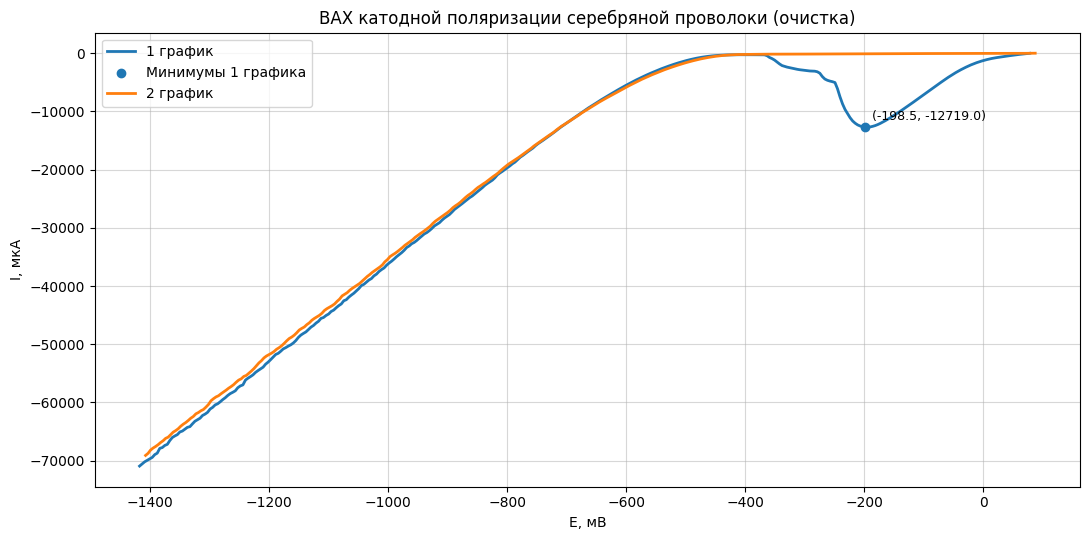

In [37]:
import numpy as np
import matplotlib.pyplot as plt

data_clr_1 = np.load(f"electrod/{not_txt_files[10]}")
E1 = data_clr_1[:, 1]
I1 = data_clr_1[:, 2]

# локальные минимумы первого графика
min_idx = np.where((I1[1:-1] < I1[:-2]) & (I1[1:-1] < I1[2:]))[0] + 1

plt.figure(figsize=(11, 5.5))
plt.plot(E1, I1, linewidth=2, label="1 график")

# отмечаем минимумы первого графика
plt.scatter(E1[min_idx], I1[min_idx], zorder=3, label="Минимумы 1 графика")

for i in min_idx:
    plt.annotate(
        f"({E1[i]:.1f}, {I1[i]:.1f})",
        xy=(E1[i], I1[i]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

# второй график
data_clr_2 = np.load(f"electrod/{not_txt_files[2]}")
E2 = data_clr_2[:, 1]
I2 = data_clr_2[:, 2]
plt.plot(E2, I2, linewidth=2, label="2 график")

plt.title("ВАХ катодной поляризации серебряной проволоки (очистка)")
plt.xlabel("E, мВ")
plt.ylabel("I, мкА")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("graph1.pdf")
plt.show()

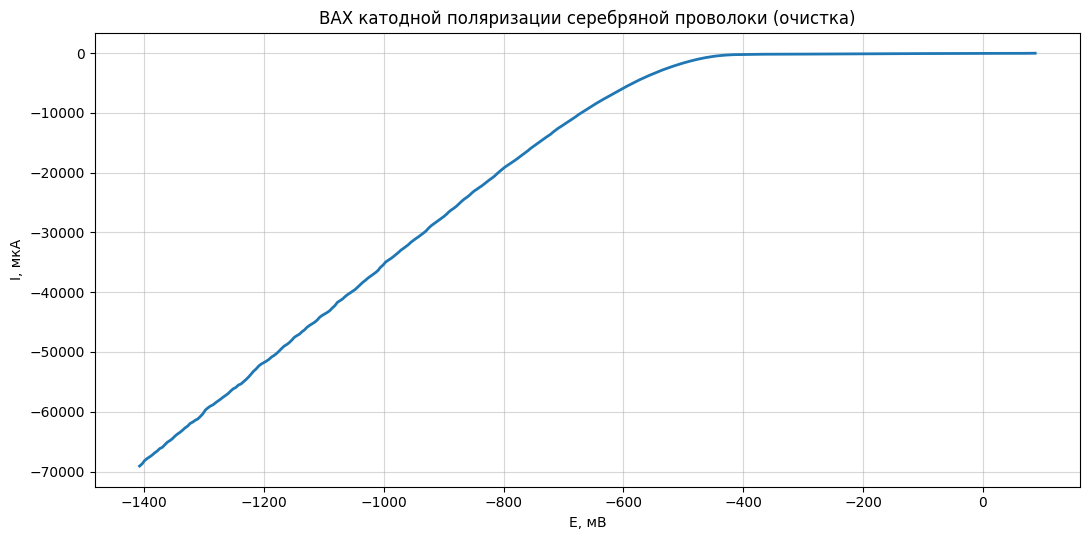

In [30]:
data_clr_1 = np.load(f"electrod/{not_txt_files[2]}")
E = data_clr_1[:, 1]
I = data_clr_1[:, 2]

plt.figure(figsize=(11, 5.5))
plt.plot(E, I, linewidth=2)
plt.title("ВАХ катодной поляризации серебряной проволоки (очистка)")
plt.xlabel("E, мВ")
plt.ylabel("I, мкА")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

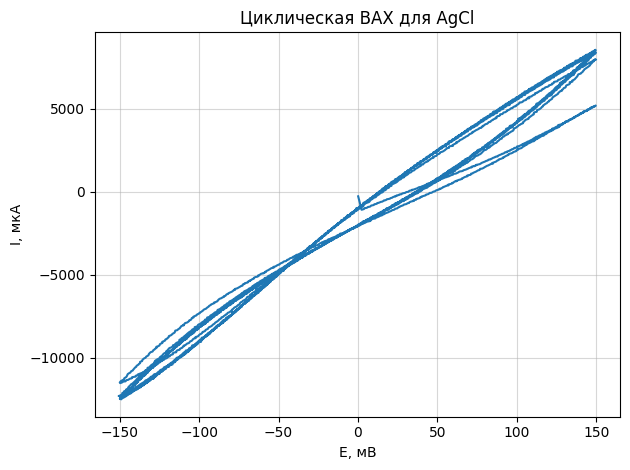

In [41]:
data_clr_1 = np.load(f"electrod/{not_txt_files[9]}")
plt.plot(data_clr_1[::, 1],data_clr_1[::, 2]) 

plt.title("Циклическая ВАХ для AgCl")
plt.xlabel("E, мВ")
plt.ylabel("I, мкА")
plt.grid(True, alpha=0.5)
# plt.legend()
plt.tight_layout()
plt.savefig("graph2.pdf")
plt.show()

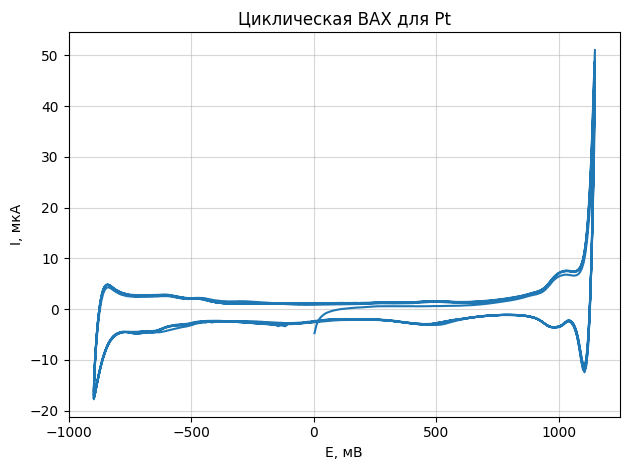

In [43]:
data_clr_1 = np.load(f"electrod/{not_txt_files[7]}")
plt.plot(data_clr_1[::, 1],data_clr_1[::, 2]) 

plt.title("Циклическая ВАХ для Pt")
plt.xlabel("E, мВ")
plt.ylabel("I, мкА")
plt.grid(True, alpha=0.5)
# plt.legend()
plt.tight_layout()
plt.savefig("graph3.pdf")
plt.show()

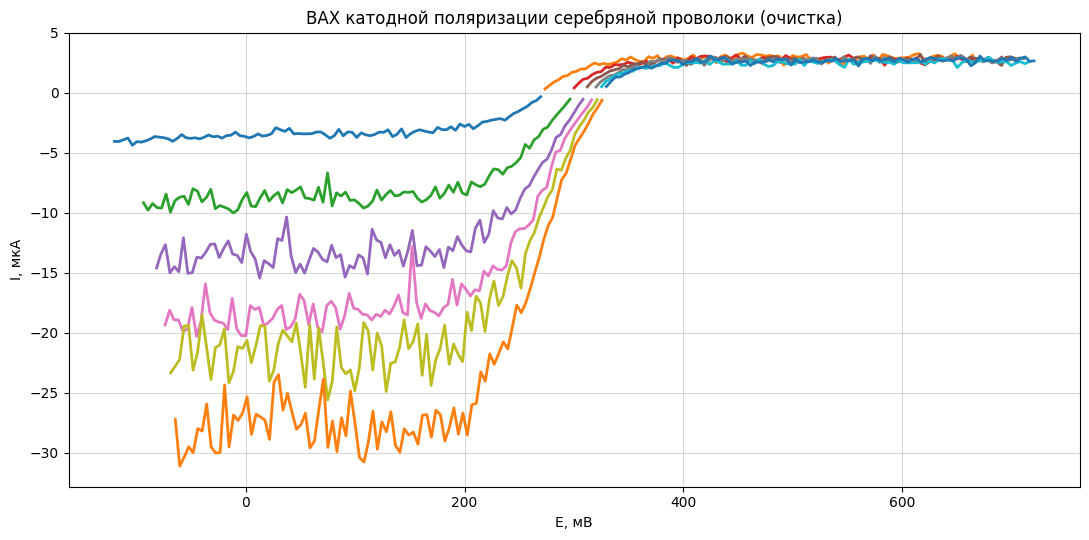

In [85]:

plt.figure(figsize=(11, 5.5))


data_1 = np.load(f"electrod/{not_txt_files[3]}")
data_2 = np.load(f"electrod/{not_txt_files[8]}")
data_clr = np.vstack((data_1, data_2))

E = data_1[:, 1]
I = data_1[:, 2]
plt.plot(E, I, linewidth=2)

E = data_2[:, 1]
I = data_2[:, 2]
plt.plot(E, I, linewidth=2)





data_1 = np.load(f"electrod/{not_txt_files[16]}")
data_2 = np.load(f"electrod/{not_txt_files[6]}")
data_clr = np.vstack((data_1, data_2))

E = data_1[:, 1]
I = data_1[:, 2]
plt.plot(E, I, linewidth=2)

E = data_2[:, 1]
I = data_2[:, 2]
plt.plot(E, I, linewidth=2)





data_1 = np.load(f"electrod/{not_txt_files[0]}")
data_2 = np.load(f"electrod/{not_txt_files[14]}")
data_clr = np.vstack((data_1, data_2))

E = data_1[:, 1]
I = data_1[:, 2]
plt.plot(E, I, linewidth=2)

E = data_2[:, 1]
I = data_2[:, 2]
plt.plot(E, I, linewidth=2)





data_1 = np.load(f"electrod/{not_txt_files[17]}")
data_2 = np.load(f"electrod/{not_txt_files[11]}")

data_clr = np.vstack((data_1, data_2))

E = data_1[:, 1]
I = data_1[:, 2]
plt.plot(E, I, linewidth=2)

E = data_2[:, 1]
I = data_2[:, 2]
plt.plot(E, I, linewidth=2)

data_1 = np.load(f"electrod/{not_txt_files[4]}")
data_2 = np.load(f"electrod/{not_txt_files[1]}")

data_clr = np.vstack((data_1, data_2))

E = data_1[:, 1]
I = data_1[:, 2]
plt.plot(E, I, linewidth=2)

E = data_2[:, 1]
I = data_2[:, 2]
plt.plot(E, I, linewidth=2)

data_1 = np.load(f"electrod/{not_txt_files[18]}")
data_2 = np.load(f"electrod/{not_txt_files[13]}")

data_clr = np.vstack((data_1, data_2))

E = data_1[:, 1]
I = data_1[:, 2]
plt.plot(E, I, linewidth=2)

E = data_2[:, 1]
I = data_2[:, 2]
plt.plot(E, I, linewidth=2)



plt.title("ВАХ катодной поляризации серебряной проволоки (очистка)")
plt.xlabel("E, мВ")
plt.ylabel("I, мкА")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig("graph4.pdf")
plt.show()

Концентрации K3[Fe(CN)6], М:
0.001923
0.005556
0.008929
0.012069
0.015000
0.017742


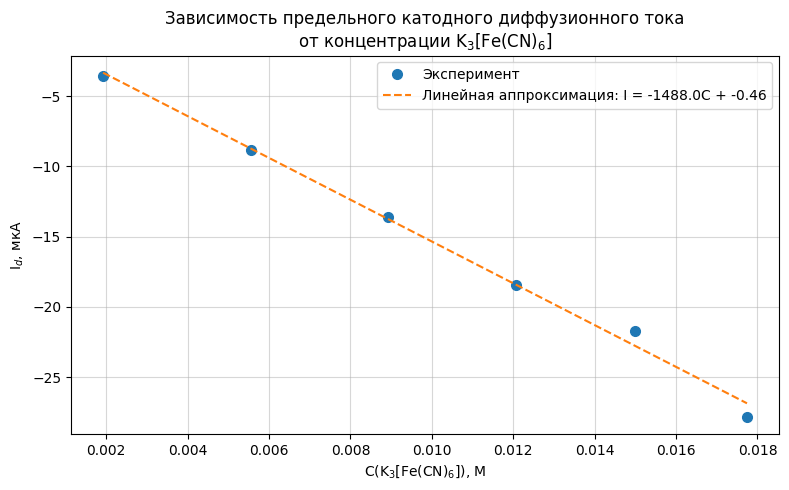

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# средние токи, мкА
I = np.array([-3.55, -8.81, -13.57, -18.44, -21.69, -27.82])

# параметры раствора
C_stock = 0.1      # М
V_water = 50       # мл
V_k3_start = 1     # мл
V_k4_start = 1     # мл
added_k3 = np.array([0, 2, 4, 6, 8, 10])   # мл, сверх начального 1 мл

# расчёт концентраций K3[Fe(CN)6]
V_total = V_water + V_k3_start + V_k4_start + added_k3          # мл
n_k3 = C_stock * (V_k3_start + added_k3) / 1000                 # моль
C_k3 = n_k3 / (V_total / 1000)                                  # М

print("Концентрации K3[Fe(CN)6], М:")
for c in C_k3:
    print(f"{c:.6f}")

# линейная аппроксимация
k, b = np.polyfit(C_k3, I, 1)
x_fit = np.linspace(C_k3.min(), C_k3.max(), 200)
y_fit = k * x_fit + b

plt.figure(figsize=(8, 5))
plt.plot(C_k3, I, 'o', markersize=7, label='Эксперимент')
plt.plot(x_fit, y_fit, '--', linewidth=1.5, label=f'Линейная аппроксимация: I = {k:.1f}C + {b:.2f}')

plt.title("Зависимость предельного катодного диффузионного тока\nот концентрации K$_3$[Fe(CN)$_6$]")
plt.xlabel("C(K$_3$[Fe(CN)$_6$]), М")
plt.ylabel("I$_d$, мкА")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("graph6.pdf")
plt.show()

/home/ivanm/mipt/sem4/physchem_labs/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ivanm/mipt/sem4/physchem_labs/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


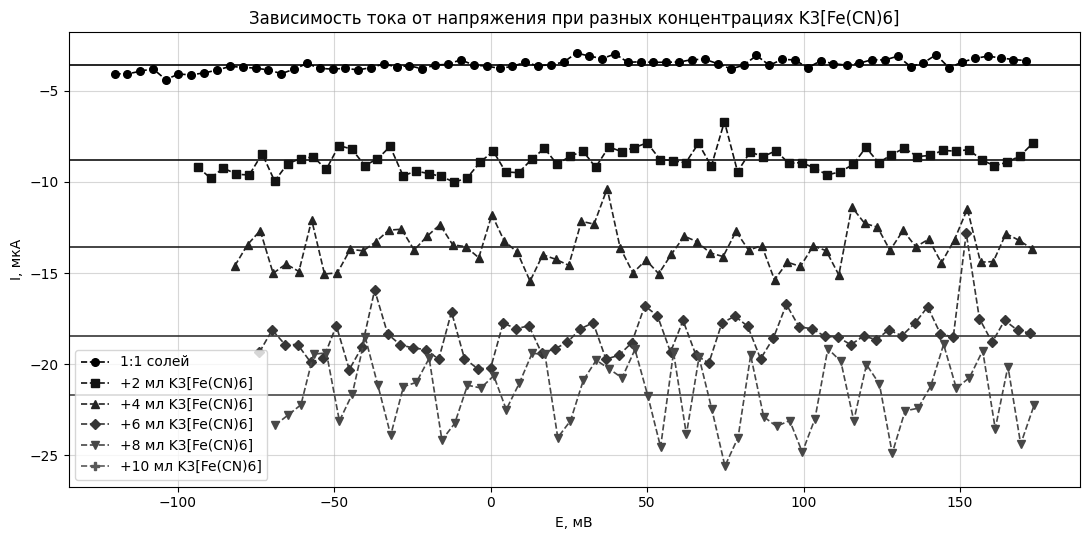

Таблица средних значений:

Раствор                Средний ток, мкА
----------------------------------------
1:1 солей                         -3.55
+2 мл K3[Fe(CN)6]                 -8.81
+4 мл K3[Fe(CN)6]                -13.57
+6 мл K3[Fe(CN)6]                -18.44
+8 мл K3[Fe(CN)6]                -21.69
+10 мл K3[Fe(CN)6]                  nan


In [89]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5.5))

curve_pairs = [
    (3, 8),
    (16, 6),
    (0, 14),
    (17, 11),
    (4, 1),
    (18, 15),
]

labels = [
    "1:1 солей",
    "+2 мл K3[Fe(CN)6]",
    "+4 мл K3[Fe(CN)6]",
    "+6 мл K3[Fe(CN)6]",
    "+8 мл K3[Fe(CN)6]",
    "+10 мл K3[Fe(CN)6]",
]

gray_values = np.linspace(0.0, 0.35, 6)
markers = ['o', 's', '^', 'D', 'v', 'P']

means = []

for (i1, i2), label, g, marker in zip(curve_pairs, labels, gray_values, markers):
    data_1 = np.load(f"electrod/{not_txt_files[i1]}")
    data_2 = np.load(f"electrod/{not_txt_files[i2]}")

    data = np.vstack((data_1, data_2))
    data = data[np.argsort(data[:, 1])]

    E = data[:, 1]
    I = data[:, 2]

    mask = E < 175
    E_cut = E[mask]
    I_cut = I[mask]

    I_mean = np.mean(I_cut)
    means.append((label, I_mean))

    plt.plot(
        E_cut, I_cut,
        linestyle='--',
        linewidth=1.2,
        marker=marker,
        markersize=5.5,
        color=(g, g, g),
        label=label
    )

    plt.axhline(
        I_mean,
        linestyle='-',
        linewidth=1.2,
        color=(g, g, g)
    )

plt.title("Зависимость тока от напряжения при разных концентрациях K3[Fe(CN)6]")
plt.xlabel("E, мВ")
plt.ylabel("I, мкА")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("graph5.pdf")
plt.show()

print("Таблица средних значений:\n")
print(f"{'Раствор':<20} {'Средний ток, мкА':>18}")
print("-" * 40)
for label, I_mean in means:
    print(f"{label:<20} {I_mean:>18.2f}")

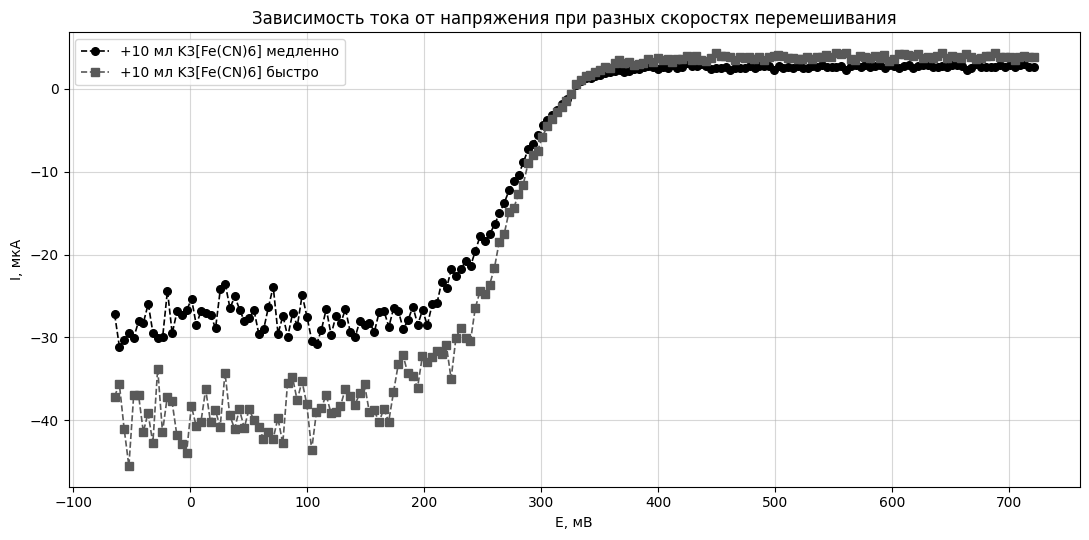

192


In [108]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5.5))

curve_pairs = [

    (18, 13),
    (12, 15),
]

labels = [
    "+10 мл K3[Fe(CN)6] медленно",
    "+10 мл K3[Fe(CN)6] быстро",
    
]

# Более контрастные оттенки серого
gray_values = np.linspace(0.0, 0.35, 2)

# Разные маркеры для ч/б печати
markers = ['o', 's', '^', 'D', 'v', 'P']

for (i1, i2), label, g, marker in zip(curve_pairs, labels, gray_values, markers):
    data_1 = np.load(f"electrod/{not_txt_files[i1]}")
    data_2 = np.load(f"electrod/{not_txt_files[i2]}")

    data = np.vstack((data_1, data_2))
    data = data[np.argsort(data[:, 1])]

    E = data[:, 1]
    I = data[:, 2]

    plt.plot(
        E, I,
        linestyle='--',
        linewidth=1.2,
        marker=marker,
        markersize=5.5,
        color=(g, g, g),
        label=label
    )

plt.title("Зависимость тока от напряжения при разных скоростях перемешивания")
plt.xlabel("E, мВ")
plt.ylabel("I, мкА")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("graph7.pdf")
plt.show()
print(len(I))

In [102]:
import numpy as np
import matplotlib.pyplot as plt

curve_pairs = [
    (3, 8),
    (16, 6),
    (0, 14),
    (17, 11),
    (4, 1),
    (18, 13),
]

labels = [
    "1:1 солей",
    "+2 мл K3[Fe(CN)6]",
    "+4 мл K3[Fe(CN)6]",
    "+6 мл K3[Fe(CN)6]",
    "+8 мл K3[Fe(CN)6]",
    "+10 мл K3[Fe(CN)6]",
]

def find_E_at_I0(data):
    data = data[np.argsort(data[:, 1])]
    E = data[:, 1]
    I = data[:, 2]

    idx = np.where(I[:-1] * I[1:] <= 0)[0]
    if len(idx) == 0:
        return np.nan

    i = idx[0]
    E1, E2 = E[i], E[i+1]
    I1, I2 = I[i], I[i+1]

    if I2 == I1:
        return E1

    return E1 - I1 * (E2 - E1) / (I2 - I1)

In [103]:
# концентрации для случая: 25 мл воды + 1 мл 0.1М K3 + 1 мл 0.1М K4
C_stock = 0.1
V_water = 25
V_k3_start = 1
V_k4_start = 1
added_k3 = np.array([0, 2, 4, 6, 8, 10])  # мл

V_total = V_water + V_k3_start + V_k4_start + added_k3
C_k3 = C_stock * (V_k3_start + added_k3) / V_total
C_k4 = C_stock * V_k4_start / V_total

ratio = C_k3 / C_k4
x = np.log(ratio)

print("C(K3), M =", C_k3)
print("C(K4), M =", C_k4)
print("ln(Ck3/Ck4) =", x)

C(K3), M = [0.0037037  0.01034483 0.01612903 0.02121212 0.02571429 0.02972973]
C(K4), M = [0.0037037  0.00344828 0.00322581 0.0030303  0.00285714 0.0027027 ]
ln(Ck3/Ck4) = [0.         1.09861229 1.60943791 1.94591015 2.19722458 2.39789527]


In [104]:
E0_points = []

for i1, i2 in curve_pairs:
    data_1 = np.load(f"electrod/{not_txt_files[i1]}")
    data_2 = np.load(f"electrod/{not_txt_files[i2]}")

    data = np.vstack((data_1, data_2))
    E_at_0 = find_E_at_I0(data)
    E0_points.append(E_at_0)

E0_points = np.array(E0_points)

print("Потенциалы при i=0, мВ:")
for label, val in zip(labels, E0_points):
    print(label, ":", val)

Потенциалы при i=0, мВ:
1:1 солей : 271.72507961635165
+2 мл K3[Fe(CN)6] : 298.70491353218614
+4 мл K3[Fe(CN)6] : 310.49974762372995
+6 мл K3[Fe(CN)6] : 318.5365936436502
+8 мл K3[Fe(CN)6] : 323.5659581419749
+10 мл K3[Fe(CN)6] : 327.99964928112706


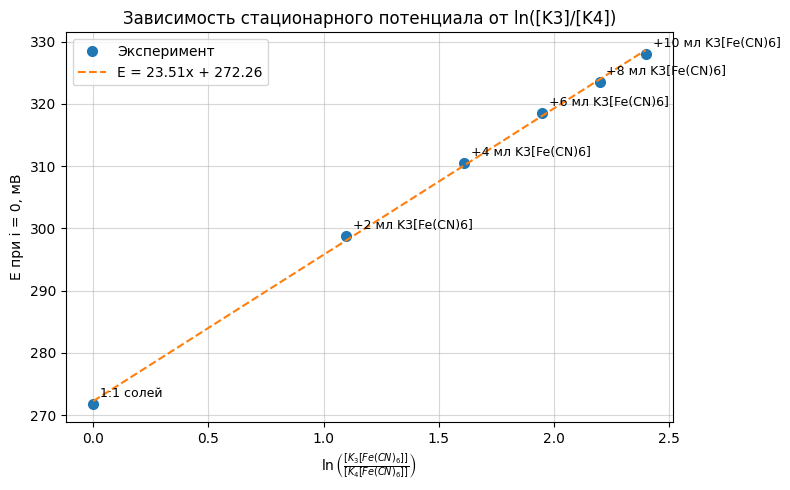

k = 23.514797896092627 мВ
b = 272.2569483673999 мВ
n = 1.0920065230651528


In [107]:
k, b = np.polyfit(x, E0_points, 1)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = k * x_fit + b

R = 8.314
T = 298
F = 96485

# E в мВ, значит переводим k в В
n = R * T / ((k / 1000) * F)

plt.figure(figsize=(8, 5))
plt.plot(x, E0_points, 'o', markersize=7, label='Эксперимент')
plt.plot(x_fit, y_fit, '--', linewidth=1.5, label=f'E = {k:.2f}x + {b:.2f}')

for xi, yi, label in zip(x, E0_points, labels):
    plt.annotate(label, (xi, yi), xytext=(5, 5), textcoords="offset points", fontsize=9)

plt.title("Зависимость стационарного потенциала от ln([K3]/[K4])")
plt.xlabel(r"$\ln\left(\frac{[K_3[Fe(CN)_6]]}{[K_4[Fe(CN)_6]]}\right)$")
plt.ylabel("E при i = 0, мВ")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("graph8.pdf")
plt.show()

print("k =", k, "мВ")
print("b =", b, "мВ")
print("n =", n)